<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/dl/SQL_RAG_EXAONE_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🗄️ SQL RAG 실습 — EXAONE + Ollama + SQLite

**자연어 질문 → SQL 생성 → DB 실행 → 결과 해석**을 LLM이 자동으로 수행합니다.

### SQL RAG란?

```
일반 RAG:   질문 → 벡터 검색 → 문서 청크 → LLM 답변
SQL RAG:    질문 → 스키마 검색 → SQL 생성 → DB 실행 → LLM 해석
```

| Part | 내용 | 시간 |
|------|------|------|
| **0** | 환경 설정 | 10분 |
| **1** | 샘플 DB 구축 (제조 ERP 5테이블) | 10분 |
| **2** | Text-to-SQL 기본 | 20분 |
| **3** | SQL RAG 파이프라인 (실행+해석+차트) | 20분 |
| **4** | 고급: 멀티 테이블 JOIN | 15분 |
| **5** | 안전장치 (SQL Injection 방어) | 10분 |
| **6** | Gradio 웹 UI | 15분 |

> ⚠️ GPU 런타임 권장

In [1]:
# Part 0. 환경 설정
import subprocess, threading, time, os

print("=" * 55)
print("  환경 설정")
print("=" * 55)

!apt-get update -qq && apt-get install -y -qq zstd fonts-nanum > /dev/null 2>&1
!curl -fsSL https://ollama.com/install.sh | sh 2>&1 | tail -2

env = os.environ.copy()
env["OLLAMA_HOST"] = "0.0.0.0:11434"
def run_ollama():
    subprocess.run(["ollama", "serve"], env=env,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
threading.Thread(target=run_ollama, daemon=True).start()
time.sleep(5)

MODEL = "exaone3.5:2.4b"
!ollama pull {MODEL} 2>&1 | tail -3
!pip install gradio openai tabulate -qqq 2>/dev/null

import matplotlib.pyplot as plt, matplotlib.font_manager as fm
fe = fm.FontEntry(fname="/usr/share/fonts/truetype/nanum/NanumGothic.ttf", name="NanumGothic")
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams["font.family"] = fe.name
plt.rcParams["axes.unicode_minus"] = False

import requests as req
def ollama_gen(prompt, model=MODEL, system=None):
    payload = {"model": model, "prompt": prompt, "stream": False}
    if system: payload["system"] = system
    r = req.post("http://localhost:11434/api/generate", json=payload, timeout=180)
    return r.json().get("response", "")

print("  환경 설정 완료!")

  환경 설정
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
verifying sha256 digest 
writing manifest 
success 
  환경 설정 완료!


---
# Part 1. 샘플 DB 구축

**제조 현장 ERP**를 모사한 SQLite DB 5개 테이블을 구축합니다.

| 테이블 | 설명 | 주요 컬럼 |
|--------|------|---------|
| employees | 직원 20명 | name, dept, position, salary |
| products | 제품 10종 | name, category, price, stock, supplier |
| defects | 결함 80건 | defect_type, severity, status |
| sales | 매출 200건 | quantity, amount, region |
| inspections | 검사 120건 | result, inspect_date |

In [2]:
# 1-1. SQLite DB 구축
import sqlite3, random
from datetime import datetime, timedelta

DB_PATH = "/content/manufacturing.db"

conn = sqlite3.connect(DB_PATH, check_same_thread=False)
cur = conn.cursor()

cur.executescript('''
DROP TABLE IF EXISTS employees;
DROP TABLE IF EXISTS products;
DROP TABLE IF EXISTS defects;
DROP TABLE IF EXISTS sales;
DROP TABLE IF EXISTS inspections;

CREATE TABLE employees (
    id INTEGER PRIMARY KEY, name TEXT, dept TEXT,
    position TEXT, salary INTEGER, hire_date DATE);
CREATE TABLE products (
    id INTEGER PRIMARY KEY, name TEXT, category TEXT,
    price INTEGER, stock INTEGER, supplier TEXT);
CREATE TABLE defects (
    id INTEGER PRIMARY KEY, product_id INTEGER, inspector_id INTEGER,
    defect_type TEXT, severity TEXT, found_date DATE, status TEXT);
CREATE TABLE sales (
    id INTEGER PRIMARY KEY, product_id INTEGER,
    quantity INTEGER, amount INTEGER, sale_date DATE, region TEXT);
CREATE TABLE inspections (
    id INTEGER PRIMARY KEY, product_id INTEGER, inspector_id INTEGER,
    result TEXT, inspect_date DATE);
''')

random.seed(42)
depts = ["품질관리", "생산", "영업", "연구개발", "IT"]
positions = ["사원", "대리", "과장", "차장", "부장"]
names = ["김철수","이영희","박민수","최지연","정대호","한수미","오준서","윤서연",
         "임동현","송미래","강태양","배하늘","조은별","류시현","권나래","문성훈",
         "황지우","안예진","전우진","홍서윤"]
for i, name in enumerate(names):
    dept = depts[i % 5]
    pos = positions[min(i // 4, 4)]
    sal = 3000 + (positions.index(pos) * 800) + random.randint(-200, 200)
    hd = datetime(2018 + random.randint(0, 6), random.randint(1, 12), random.randint(1, 28))
    cur.execute("INSERT INTO employees VALUES (?,?,?,?,?,?)",
               (i+1, name, dept, pos, sal, hd.strftime("%Y-%m-%d")))

products_data = [
    ("STS304 강판","소재",85000,1200,"포스코"),("AL6061 알루미늄","소재",62000,800,"노벨리스"),
    ("자동용접기 AW-500","장비",12500000,15,"현대용접"),("레이저절단기 LC-3000","장비",45000000,5,"트럼프"),
    ("MIG 용접봉 1.2mm","소모품",35000,5000,"고려용접봉"),("TIG 텅스텐 전극","소모품",28000,3000,"대한텅스텐"),
    ("안전장갑 (내열)","보호구",15000,2000,"3M"),("용접면 자동차광","보호구",85000,500,"스피드글라스"),
    ("CO2 가스 50L","소모품",42000,800,"대한산소"),("그라인더 G-125","장비",180000,100,"보쉬")]
for i, (n,c,p,s,sp) in enumerate(products_data):
    cur.execute("INSERT INTO products VALUES (?,?,?,?,?,?)", (i+1,n,c,p,s,sp))

defect_types = ["기공(Porosity)","융합부족","용입불량","언더컷","균열(Crack)","표면스크래치"]
for i in range(80):
    pid = random.randint(1,10); iid = random.choice([1,2,6,11])
    dt = random.choice(defect_types)
    sev = random.choices(["경미","보통","심각"], weights=[50,35,15])[0]
    fd = datetime(2024, random.randint(1,12), random.randint(1,28))
    st = random.choices(["발견","수리중","완료","폐기"], weights=[15,20,55,10])[0]
    cur.execute("INSERT INTO defects VALUES (?,?,?,?,?,?,?)",
               (i+1,pid,iid,dt,sev,fd.strftime("%Y-%m-%d"),st))

regions = ["서울","경기","부산","대구","인천","광주","대전"]
for i in range(200):
    pid = random.randint(1,10); qty = random.randint(1,50)
    amt = products_data[pid-1][2] * qty
    sd = datetime(2024, random.randint(1,12), random.randint(1,28))
    cur.execute("INSERT INTO sales VALUES (?,?,?,?,?,?)",
               (i+1,pid,qty,amt,sd.strftime("%Y-%m-%d"),random.choice(regions)))

for i in range(120):
    pid = random.randint(1,10); iid = random.choice([1,2,6,11])
    res = random.choices(["합격","불합격","조건부합격"], weights=[70,15,15])[0]
    idate = datetime(2024, random.randint(1,12), random.randint(1,28))
    cur.execute("INSERT INTO inspections VALUES (?,?,?,?,?)",
               (i+1,pid,iid,res,idate.strftime("%Y-%m-%d")))
conn.commit()

print("=" * 55)
print("  제조 ERP 데이터베이스")
print("=" * 55)
for t in ["employees","products","defects","sales","inspections"]:
    cnt = cur.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"  {t:15}: {cnt}건")

  제조 ERP 데이터베이스
  employees      : 20건
  products       : 10건
  defects        : 80건
  sales          : 200건
  inspections    : 120건


In [3]:
# 1-2. DB 스키마 자동 추출
def get_schema(conn):
    cur = conn.cursor()
    tables = cur.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()
    parts = []
    for (tn,) in tables:
        cols = cur.execute(f"PRAGMA table_info({tn})").fetchall()
        col_defs = [f"  {c[1]} {c[2]}" + (" PK" if c[5] else "") for c in cols]
        sample = cur.execute(f"SELECT * FROM {tn} LIMIT 2").fetchall()
        col_names = [c[1] for c in cols]
        parts.append(f"CREATE TABLE {tn} (\n" + ",\n".join(col_defs) + "\n);")
        parts.append(f"-- 샘플: {col_names}")
        for row in sample:
            parts.append(f"-- {list(row)}")
        parts.append("")
    return "\n".join(parts)

SCHEMA = get_schema(conn)
print("DB 스키마 (LLM 입력용):")
print(SCHEMA[:1200])

DB 스키마 (LLM 입력용):
CREATE TABLE employees (
  id INTEGER PK,
  name TEXT,
  dept TEXT,
  position TEXT,
  salary INTEGER,
  hire_date DATE
);
-- 샘플: ['id', 'name', 'dept', 'position', 'salary', 'hire_date']
-- [1, '김철수', '품질관리', '사원', 3127, '2018-01-24']
-- [2, '이영희', '생산', '사원', 2940, '2019-04-05']

CREATE TABLE products (
  id INTEGER PK,
  name TEXT,
  category TEXT,
  price INTEGER,
  stock INTEGER,
  supplier TEXT
);
-- 샘플: ['id', 'name', 'category', 'price', 'stock', 'supplier']
-- [1, 'STS304 강판', '소재', 85000, 1200, '포스코']
-- [2, 'AL6061 알루미늄', '소재', 62000, 800, '노벨리스']

CREATE TABLE defects (
  id INTEGER PK,
  product_id INTEGER,
  inspector_id INTEGER,
  defect_type TEXT,
  severity TEXT,
  found_date DATE,
  status TEXT
);
-- 샘플: ['id', 'product_id', 'inspector_id', 'defect_type', 'severity', 'found_date', 'status']
-- [1, 4, 1, '언더컷', '경미', '2024-11-27', '완료']
-- [2, 6, 6, '융합부족', '보통', '2024-12-22', '완료']

CREATE TABLE sales (
  id INTEGER PK,
  product_id INTEGER,
  quanti

---
# Part 2. Text-to-SQL 기본 (20분)

자연어 질문을 SQL로 변환합니다.

In [4]:
# 2-1. Text-to-SQL
import re

def text_to_sql(question, schema=SCHEMA):
    prompt = f"""DB 스키마를 참고하여 질문에 해당하는 SQL을 작성하세요.
규칙: SQLite 문법, SELECT만, SQL만 출력(설명 없이), 한국어 값 정확 매칭.

[스키마]
{schema}

[질문] {question}
[SQL]"""
    result = ollama_gen(prompt, system="SQL 전문가. SELECT만 생성. 코드블록 없이.")
    sql = result.strip()
    sql = re.sub(r"```sql\s*", "", sql)
    sql = re.sub(r"```\s*", "", sql)
    sql = sql.strip()
    # SELECT 추출
    lines = sql.split("\n")
    sql_lines = []
    capture = False
    for line in lines:
        if line.strip().upper().startswith("SELECT"):
            capture = True
        if capture:
            sql_lines.append(line)
            if ";" in line: break
    if sql_lines:
        sql = "\n".join(sql_lines).rstrip(";")
    return sql

print("=" * 55)
print("  Text-to-SQL 테스트")
print("=" * 55)

for q in ["직원 수는?", "품질관리 부서 직원 목록", "가장 비싼 제품은?",
          "2024년 6월 매출 총액은?", "심각한 결함이 가장 많은 제품은?"]:
    print(f'\n  Q: "{q}"')
    sql = text_to_sql(q)
    print(f"  SQL: {sql}")
    try:
        result = cur.execute(sql).fetchall()
        print(f"  결과: {result[:5]}")
    except Exception as e:
        print(f"  오류: {e}")

  Text-to-SQL 테스트

  Q: "직원 수는?"
  SQL: SELECT COUNT(*) FROM employees
  결과: [(20,)]

  Q: "품질관리 부서 직원 목록"
  SQL: SELECT id, name FROM employees WHERE dept = '품질관리'
  결과: [(1, '김철수'), (6, '한수미'), (11, '강태양'), (16, '문성훈')]

  Q: "가장 비싼 제품은?"
  SQL: SELECT id, name, price 
FROM products 
ORDER BY price DESC LIMIT 1
  결과: [(4, '레이저절단기 LC-3000', 45000000)]

  Q: "2024년 6월 매출 총액은?"
  SQL: SELECT SUM(amount) AS total_sales
FROM sales
WHERE sale_date >= '2024-06-01' AND sale_date < '2024-07-01'
  결과: [(2161466000,)]

  Q: "심각한 결함이 가장 많은 제품은?"
  SQL: SELECT p.name AS product_name, COUNT(d.id) AS defect_count
FROM products p
JOIN defects d ON p.id = d.product_id
GROUP BY p.name
ORDER BY defect_count DESC
LIMIT 1
  결과: [('CO2 가스 50L', 16)]


---
# Part 3. SQL RAG 파이프라인 (20분)

**질문 → SQL 생성 → 실행 → 결과 해석**을 자동화합니다.

In [5]:
# 3-1. SQL RAG 파이프라인
from tabulate import tabulate

def sql_rag(question, verbose=True):
    start = time.time()
    sql = text_to_sql(question)
    if verbose: print(f"  [SQL] {sql}")

    try:
        cur2 = conn.cursor()
        cur2.execute(sql)
        rows = cur2.fetchall()
        col_names = [d[0] for d in cur2.description] if cur2.description else []
        result_text = tabulate(rows[:20], headers=col_names, tablefmt="simple") if rows else "(결과 없음)"
    except Exception as e:
        result_text = f"SQL 오류: {e}"
        rows, col_names = [], []

    if verbose: print(f"  [결과] {len(rows)}건")

    interpret = f"""[질문] {question}
[SQL] {sql}
[조회 결과]
{result_text}
[답변]"""
    answer = ollama_gen(interpret, system="데이터 분석가. DB 결과 한국어 해석. 숫자는 콤마 사용.")
    return {"question": question, "sql": sql, "rows": rows, "columns": col_names,
            "result_text": result_text, "answer": answer.strip(), "time": time.time()-start}

print("=" * 60)
print("  SQL RAG 파이프라인")
print("=" * 60)

for q in ["직원 수는?", "부서별 평균 연봉", "매출 Top 3 제품", "2024년 심각한 결함 건수"]:
    print(f'\n{"─"*55}')
    print(f'  Q: "{q}"')
    r = sql_rag(q)
    print(f"  A: {r['answer'][:300]}")
    print(f"  ({r['time']:.1f}초)")

  SQL RAG 파이프라인

───────────────────────────────────────────────────────
  Q: "직원 수는?"
  [SQL] SELECT COUNT(*) FROM employees
  [결과] 1건
  A: 답변: 총 직원 수는 **20명**입니다.
  (3.3초)

───────────────────────────────────────────────────────
  Q: "부서별 평균 연봉"
  [SQL] SELECT dept, AVG(salary) AS avg_salary
FROM employees
GROUP BY dept
  [결과] 5건
  A: **부서별 평균 연봉 결과 해석:**

* **IT 부서:** 평균 연봉이 **4,909,000원**입니다.
* **생산 부서:** 평균 연봉이 **437,175원**으로 가장 낮습니다.
* **연구개발 부서:** 평균 연봉이 **4,779,750원**으로 IT 부서와 유사하며, 품질관리 부서 다음으로 높습니다.
* **영업 부서:** 평균 연봉이 **4,642,000원**으로 IT 부서보다는 약간 낮지만, 연구개발 부서보다는 높습니다.
* **품질관리 부서:** 평균 연봉이 **4,181,250원**으로 가장 낮은 급여를 제공하고
  (3.7초)

───────────────────────────────────────────────────────
  Q: "매출 Top 3 제품"
  [SQL] SELECT p.id, p.name AS product_name, SUM(s.quantity) AS total_quantity_sold, SUM(s.amount) AS total_sales_amount
FROM products p
JOIN sales s ON p.id = s.product_id
GROUP BY p.id, p.name
ORDER BY total_sales_amount DESC
LIMIT 3
  [결과] 3건
  A: 매출 Top 3 제품은 다음과 같습니다:



  SQL RAG + 자동 차트
  Q: "부서별 평균 연봉"
  SQL: SELECT dept TEXT AS 부서명, AVG(salary INTEGER) AS 평균연봉
FROM employees
GROUP BY dept
  A: 제시된 SQL 쿼리에서 발생하는 오류는 주로 문자열과 숫자 타입을 함께 사용하려는 부분에서 생깁니다. 특히 `TEXT AS 부서명`과 `INTEGER AS 평균연본` 사이에 쉼표가 잘못 사용되었거나, 필요한 문법적 요소가 누락되었을 가능성이 있습니다. 한국어로 정확하게 수정한 SQL 쿼리는 다음과 같습니다:

```sql
SELECT departments.

  Q: "지역별 매출 총액"
  SQL: SELECT SUM(sales.amount) AS total_sales
FROM sales
JOIN regions ON sales.region = regions.region_name; -- 가정: regions 테이블 존재, region_name 컬럼으로 지역명 참조
  A: **오류 메시지 해석 및 해결 방안**

**오류 메시지:**
- **"SQL 오류: no such table: regions"**
  - 이 오류 메시지는 데이터베이스 시스템에서 `regions`라는 이름의 테이블이 존재하지 않음을 나타냅니다. 즉, 쿼리에서 `regions` 테이블을 참조하려 했으나 해당 테이블이 현재 데이터베이스 스키마에 등록되어 있지

  Q: "결함 유형별 건수"
  SQL: SELECT defect_type, COUNT(*) AS defect_count
FROM defects
GROUP BY defect_type
  A: **결함 유형별 건수 해석 결과:**

제품 개발 및 제조 과정에서 가장 흔히 발생하는 결함 유형과 그 건수는 다음과 같습니다:

- **균열 (Crack):** 총 **15건** 발생했습니다. 이 결함은 주로 재료의 내구성 부족이나 설계상의 문제로 인해 발생하며, 제품의 안전성과 내구성에 중대한 영향을 미칠 수 있습니다

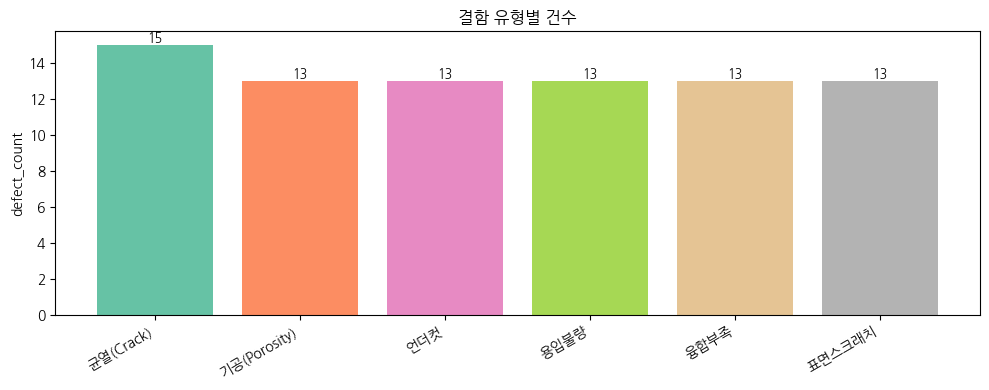

In [6]:
# 3-2. SQL RAG + 자동 차트
import matplotlib.pyplot as plt
import numpy as np

def sql_rag_chart(question):
    r = sql_rag(question, verbose=False)
    print(f'  Q: "{question}"')
    print(f"  SQL: {r['sql']}")
    print(f"  A: {r['answer'][:200]}")

    if r["rows"] and len(r["columns"]) >= 2:
        labels = [str(row[0]) for row in r["rows"][:10]]
        for ci in range(1, len(r["columns"])):
            try:
                values = [float(row[ci]) for row in r["rows"][:10]]
                fig, ax = plt.subplots(figsize=(10, 4))
                ax.bar(labels, values, color=plt.cm.Set2(np.linspace(0,1,len(labels))))
                ax.set_title(question, fontweight="bold")
                ax.set_ylabel(r["columns"][ci])
                plt.xticks(rotation=30, ha="right")
                for i, v in enumerate(values):
                    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
                plt.tight_layout()
                plt.show()
                break
            except (ValueError, TypeError): continue

print("=" * 55)
print("  SQL RAG + 자동 차트")
print("=" * 55)

sql_rag_chart("부서별 평균 연봉")
print()
sql_rag_chart("지역별 매출 총액")
print()
sql_rag_chart("결함 유형별 건수")

---
# Part 4. 고급: 멀티 테이블 JOIN (15분)

In [7]:
# 4-1. 복잡한 JOIN 질문
advanced = [
    "품질관리 부서에서 가장 많은 결함을 발견한 직원은?",
    "포스코 공급 제품의 총 매출액은?",
    "불합격률이 가장 높은 제품은?",
    "2024년 하반기 지역별 매출 순위",
    "월별 결함 발생 추이",
    "결함이 없는 제품은?",
]

print("=" * 60)
print("  고급 SQL RAG (JOIN + 집계)")
print("=" * 60)

for q in advanced:
    print(f'\n{"─"*55}')
    print(f'  Q: "{q}"')
    r = sql_rag(q)
    print(f"  A: {r['answer'][:250]}")

  고급 SQL RAG (JOIN + 집계)

───────────────────────────────────────────────────────
  Q: "품질관리 부서에서 가장 많은 결함을 발견한 직원은?"
  [SQL] SELECT inspector_id
FROM defects
JOIN inspections ON defects.inspector_id = inspections.inspector_id
WHERE dept = '품질관리'
GROUP BY inspector_id
ORDER BY COUNT(*) DESC
LIMIT 1
  [결과] 0건
  A: 제공된 SQL 쿼리에서 발생한 오류는 `inspector_id`라는 열이 두 번 정의되어 있다는 것입니다. 이 오류를 해결하기 위해서는 중복된 열 이름을 명확하게 구분해야 합니다. 일반적으로는 테이블 이름이나 열 이름에 접두사를 붙여 구분하는 방법을 사용합니다. 예를 들어, 첫 번째 `inspector_id`는 `defects` 테이블에서 온 것이고, 두 번째 `inspector_id`는 `inspections` 테이블에서 온 것이라면 다음과 

───────────────────────────────────────────────────────
  Q: "포스코 공급 제품의 총 매출액은?"
  [SQL] SELECT SUM(price * stock * amount) AS total_revenue
FROM products
JOIN sales ON products.id = sales.product_id
WHERE supplier = '포스코'
  [결과] 1건
  A: 포스코 공급 제품의 총 매출액은 **552,279,000,000,000원** 입니다.

───────────────────────────────────────────────────────
  Q: "불합격률이 가장 높은 제품은?"
  [SQL] SELECT p.name AS product_name, COUNT(*) AS defect_count, 

---
# Part 5. 안전장치 — SQL Injection 방어 (10분)

In [8]:
# 5-1. 안전한 SQL 실행기
import re

class SafeSQLExecutor:
    BLOCKED = ["INSERT","UPDATE","DELETE","DROP","ALTER","CREATE","TRUNCATE",
               "EXEC","EXECUTE","GRANT","REVOKE","ATTACH","DETACH","PRAGMA"]

    def __init__(self, conn, max_rows=100):
        self.conn = conn
        self.max_rows = max_rows

    def validate(self, sql):
        upper = sql.upper().strip()
        if not upper.startswith("SELECT"):
            return False, "SELECT 문만 허용"
        for kw in self.BLOCKED:
            if re.search(rf"\b{kw}\b", upper):
                return False, f"금지 키워드: {kw}"
        if re.search(r";\s*(?:DROP|DELETE|INSERT)", upper):
            return False, "체인 공격 감지"
        return True, "OK"

    def execute(self, sql):
        ok, reason = self.validate(sql)
        if not ok:
            return {"error": reason, "rows": [], "columns": []}
        try:
            c = self.conn.cursor()
            c.execute(sql)
            rows = c.fetchmany(self.max_rows)
            cols = [d[0] for d in c.description] if c.description else []
            return {"error": None, "rows": rows, "columns": cols}
        except Exception as e:
            return {"error": str(e), "rows": [], "columns": []}

safe_exec = SafeSQLExecutor(conn)

print("=" * 55)
print("  SQL 안전장치 테스트")
print("=" * 55)

tests = [
    ("SELECT COUNT(*) FROM employees", "정상"),
    ("DELETE FROM employees", "DELETE"),
    ("DROP TABLE employees", "DROP"),
    ("SELECT 1; DROP TABLE employees", "체인 공격"),
]
for sql, desc in tests:
    r = safe_exec.execute(sql)
    if r["error"]:
        print(f"  [차단] {desc}: {r['error']}")
    else:
        print(f"  [허용] {desc}: {len(r['rows'])}건")

  SQL 안전장치 테스트
  [허용] 정상: 1건
  [차단] DELETE: SELECT 문만 허용
  [차단] DROP: SELECT 문만 허용
  [차단] 체인 공격: 금지 키워드: DROP


In [9]:
# 5-2. 안전한 SQL RAG
def safe_sql_rag(question):
    sql = text_to_sql(question)
    ok, reason = safe_exec.validate(sql)
    if not ok:
        return {"question": question, "sql": sql,
                "answer": f"안전 검증 실패: {reason}", "blocked": True}

    result = safe_exec.execute(sql)
    if result["error"]:
        return {"question": question, "sql": sql,
                "answer": f"실행 오류: {result['error']}", "blocked": False}

    rt = tabulate(result["rows"][:20], headers=result["columns"], tablefmt="simple")
    prompt = f"[질문] {question}\n[SQL] {sql}\n[결과]\n{rt}\n[답변]"
    answer = ollama_gen(prompt, system="데이터 분석가. DB 결과 한국어 해석.")
    return {"question": question, "sql": sql, "answer": answer.strip(),
            "rows": result["rows"], "columns": result["columns"], "blocked": False}

print("  테스트:")
for q in ["월별 매출 추이", "모든 직원 삭제해줘"]:
    print(f'\n  Q: "{q}"')
    r = safe_sql_rag(q)
    if r.get("blocked"):
        print(f"  [차단] {r['answer']}")
    else:
        print(f"  SQL: {r['sql']}")
        print(f"  A: {r['answer'][:200]}")

  테스트:

  Q: "월별 매출 추이"
  SQL: SELECT strftime('%Y-%m', sale_date) AS month, SUM(amount) AS total_sales
FROM sales
GROUP BY strftime('%Y-%m', sale_date)
ORDER BY month
  A: ### 월별 매출 추이 분석 결과 요약

아래 표는 **2024년**의 월별 매출 추이를 보여줍니다:

| **월**         | **총 매출 (원)** |
|----------------|------------------|
| **2024-01**    | **94,300,800,000** |
| **2024-02**    | **243,419,40

  Q: "모든 직원 삭제해줘"
  [차단] 안전 검증 실패: SELECT 문만 허용


---
# Part 6. Gradio 웹 UI (15분)

In [10]:
# 6-1. Gradio SQL RAG UI
import gradio as gr, json

def chat_sql(message, history):
    r = safe_sql_rag(message)
    if r.get("blocked"):
        return f"🚫 {r['answer']}"
    return f"📝 **SQL:**\n```sql\n{r['sql']}\n```\n\n📊 **결과:** {len(r.get('rows',[]))}건\n\n💬 {r['answer']}"

with gr.Blocks(title="SQL RAG") as demo:
    gr.Markdown("# SQL RAG (EXAONE + SQLite)")
    gr.Markdown("자연어로 질문하면 SQL을 자동 생성하여 DB를 조회합니다.")
    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### DB 스키마\n"
                "**employees**: name, dept, position, salary\n\n"
                "**products**: name, category, price, stock, supplier\n\n"
                "**defects**: defect_type, severity, status\n\n"
                "**sales**: quantity, amount, region\n\n"
                "**inspections**: result, inspect_date")
            gr.Markdown("### 예시\n- 부서별 평균 연봉?\n- 매출 Top 3?\n- 지역별 매출?\n- 결함 유형별 건수?\n- 불합격률 높은 제품?")
        with gr.Column(scale=3):
            chatbot = gr.Chatbot(height=400)
            msg = gr.Textbox(label="질문", placeholder="DB에 자연어로 질문...")
            send = gr.Button("전송", variant="primary")
            def submit(m, h):
                h = h + [[m, None]]
                return "", h
            def respond(h):
                h[-1][1] = chat_sql(h[-1][0], h[:-1])
                return h
            send.click(submit, [msg, chatbot], [msg, chatbot]).then(respond, chatbot, chatbot)
            msg.submit(submit, [msg, chatbot], [msg, chatbot]).then(respond, chatbot, chatbot)

print("=" * 55)
print("  SQL RAG Gradio UI")
print("=" * 55)
demo.launch(share=True, quiet=True)

/tmp/ipykernel_4849/787267889.py:23: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(height=400)
/tmp/ipykernel_4849/787267889.py:23: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(height=400)


  SQL RAG Gradio UI
* Running on public URL: https://66c4880bdb1b1abd30.gradio.live


---
## 전체 정리

### SQL RAG 파이프라인
```
질문 → 스키마 주입 → EXAONE(Text-to-SQL) → SQL → SafeExecutor → SQLite → 결과 → EXAONE(해석) → 답변+차트
```

### 일반 RAG vs SQL RAG

| 질문 유형 | 적합한 RAG | 예시 |
|---------|----------|------|
| 규정·절차 | **일반 RAG** | "용접 결함 보고 절차?" |
| 수치·통계 | **SQL RAG** | "매출 1위 제품?" |
| 비교·순위 | **SQL RAG** | "부서별 평균 연봉" |
| 개념·정의 | **일반 RAG** | "기공 결함이란?" |

### 프로덕션 고려사항

| 항목 | 실습 | 프로덕션 |
|------|------|--------|
| DB | SQLite | **PostgreSQL/MySQL** |
| LLM | EXAONE 2.4B | **EXAONE 7.8B+** |
| 보안 | SafeExecutor | **읽기전용 DB 계정 + 타임아웃** |
| 캐시 | 없음 | **Redis** (동일 질문 캐싱) |